Here is the excerpt from the paper that tells us the values of alpha and beta:


We present our ZTF Hubble diagram for the 2629 non-peculiar SNe~Ia that pass our quality cuts in Figure~6. These SNe~Ia have been standardized using the methodology detailed in Ginolin et~al.~(2024), given the SALT2 stretch and color parameters and host local environmental properties (for example, Sullivan et~al.~2010; Rigault et~al.~2020). Following that paper, we adopt the nuisance parameter values $\alpha = -0.16$, $\beta = 3.05$, and $\gamma = 0.145~\mathrm{mag}$ (local-color step).


The standardized distance modulus for each Type~Ia supernova is computed using the Tripp (1998) relation:

The observed distance modulus in the SALT2 framework is given by: 

$
\mu_{\mathrm{obs}} = -2.5 \log_{10}(x_0) + \alpha x_1 - \beta c
$

Link to paper: [doi.org/10.1051/0004-6361/202450943](https://www.aanda.org/articles/aa/full_html/2025/02/aa50943-24/aa50943-24.html)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from scipy.optimize import minimize_scalar
from astropy.stats import sigma_clip

# Lets First Do Some Host Galaxy Quality Cuts on Our Sample #

Judging from the following 

In [2]:
# Read the following file:

df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop.csv")
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540 entries, 0 to 539
Data columns (total 65 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ZTF_Unnamed: 0                    539 non-null    float64
 1   ztfname                           539 non-null    object 
 2   ZTF_redshift                      539 non-null    float64
 3   ZTF_redshift_err                  539 non-null    float64
 4   ZTF_source                        539 non-null    object 
 5   ZTF_t0                            539 non-null    float64
 6   ZTF_x0                            539 non-null    float64
 7   ZTF_x1                            539 non-null    float64
 8   ZTF_c                             539 non-null    float64
 9   ZTF_t0_err                        539 non-null    float64
 10  ZTF_x0_err                        539 non-null    float64
 11  ZTF_x1_err                        539 non-null    float64
 12  ZTF_c_er

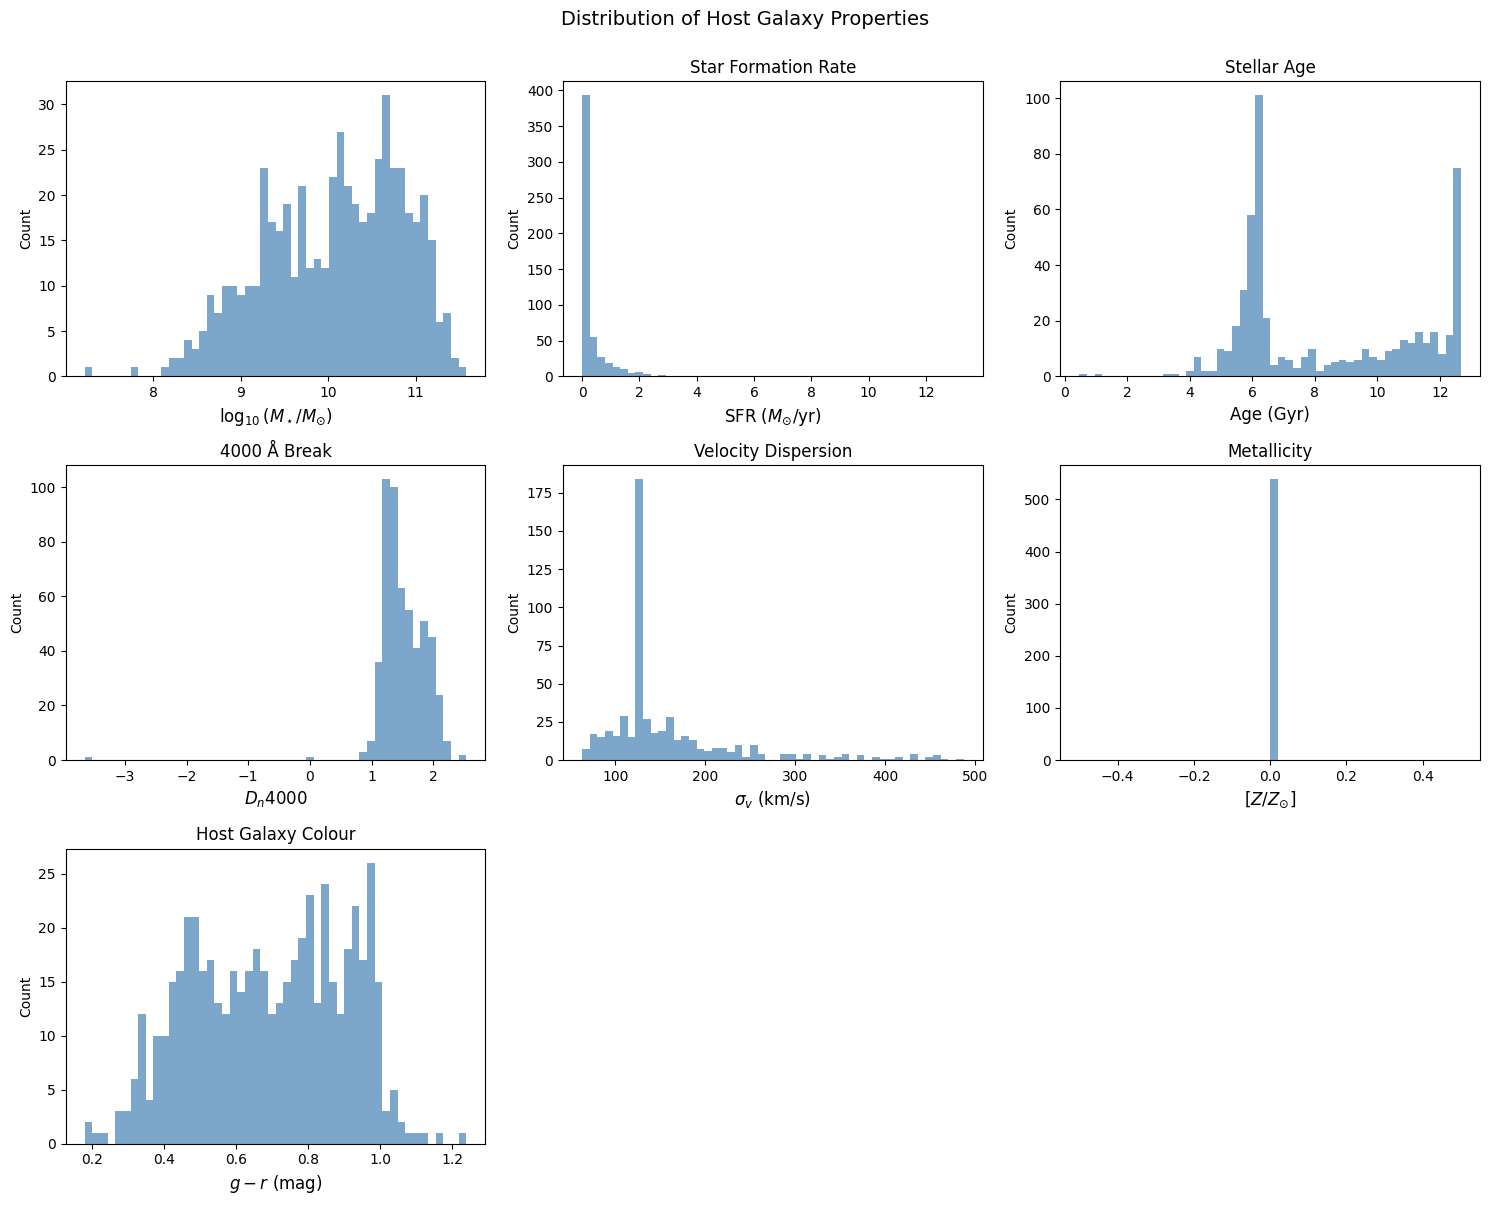

In [3]:
df["DESI_FASTSPEC_g_minus_r"] = df["DESI_FASTSPEC_ABSMAG01_SDSS_G"] - df["DESI_FASTSPEC_ABSMAG01_SDSS_R"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

ax = axes[0, 0]
ax.hist(df["DESI_FASTSPEC_LOGMSTAR"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$", fontsize=12)
ax.set_ylabel("Count")

ax = axes[0, 1]
ax.hist(df["DESI_FASTSPEC_SFR"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"SFR $(M_{\odot}/\mathrm{yr})$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Star Formation Rate")

ax = axes[0, 2]
ax.hist(df["DESI_FASTSPEC_AGE"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"Age (Gyr)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Stellar Age")

ax = axes[1, 0]
ax.hist(df["DESI_FASTSPEC_DN4000"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$D_n4000$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("4000 Å Break")

ax = axes[1, 1]
ax.hist(df["DESI_FASTSPEC_VDISP"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$\sigma_v$ (km/s)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Velocity Dispersion")

ax = axes[1, 2]
ax.hist(df["DESI_FASTSPEC_ZZSUN"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$[Z/Z_{\odot}]$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Metallicity")

ax = axes[2, 0]
ax.hist(df["DESI_FASTSPEC_g_minus_r"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$g - r$ (mag)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Host Galaxy Colour")

axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)

fig.suptitle("Distribution of Host Galaxy Properties", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

# Now Lets Get some Quality Cuts Defined and See What the Final Histograms Looks Like #

In [4]:
print(f"Before cuts: {len(df)}")

mask_sfr = df["DESI_FASTSPEC_SFR"] <= 2.5
print(f"SFR <= 2.5:    {mask_sfr.sum()} keep, {(~mask_sfr).sum()} dropped")
df = df[mask_sfr].reset_index(drop=True)

mask_dn4000 = df["DESI_FASTSPEC_DN4000"] >= 0.5
print(f"DN4000 >= 0.5: {mask_dn4000.sum()} keep, {(~mask_dn4000).sum()} dropped")
df = df[mask_dn4000].reset_index(drop=True)

mask_age = df["DESI_FASTSPEC_AGE"] >= 2
print(f"AGE >= 2 Gyr:  {mask_age.sum()} keep, {(~mask_age).sum()} dropped")
df = df[mask_age].reset_index(drop=True)

print(f"After all cuts: {len(df)}")

Before cuts: 540
SFR <= 2.5:    531 keep, 9 dropped
DN4000 >= 0.5: 529 keep, 2 dropped
AGE >= 2 Gyr:  527 keep, 2 dropped
After all cuts: 527


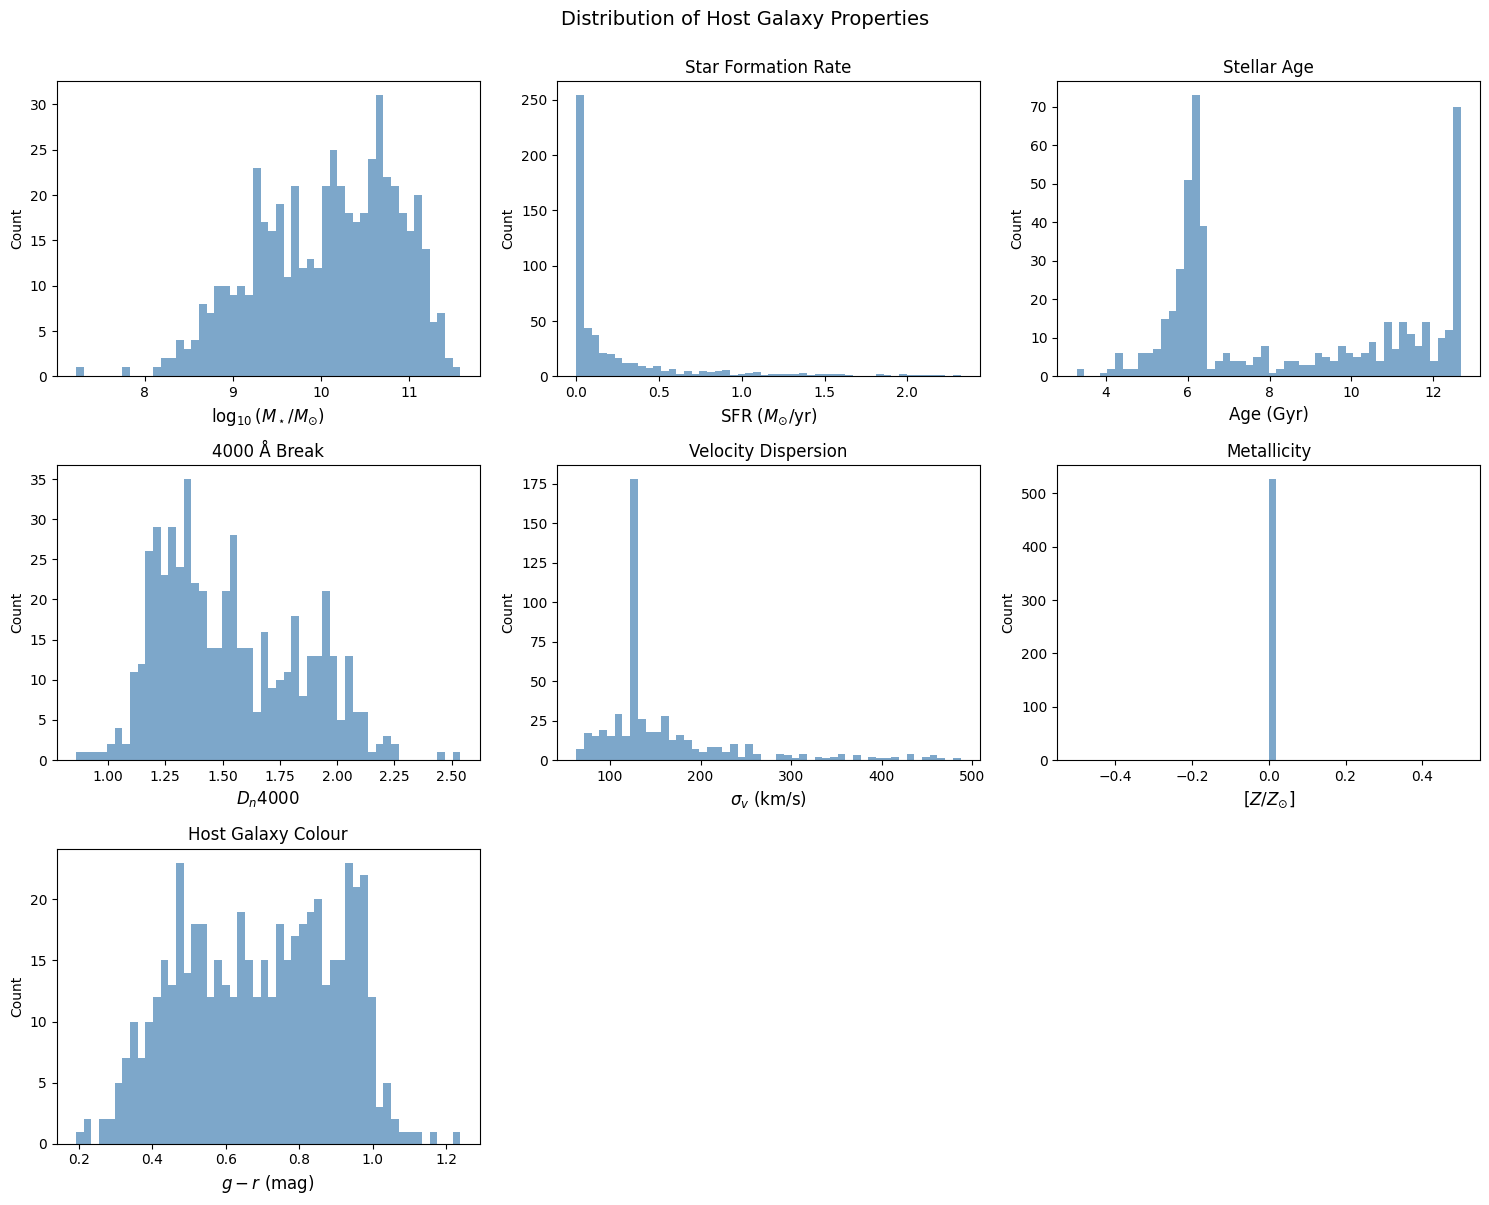

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

ax = axes[0, 0]
ax.hist(df["DESI_FASTSPEC_LOGMSTAR"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$", fontsize=12)
ax.set_ylabel("Count")

ax = axes[0, 1]
ax.hist(df["DESI_FASTSPEC_SFR"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"SFR $(M_{\odot}/\mathrm{yr})$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Star Formation Rate")

ax = axes[0, 2]
ax.hist(df["DESI_FASTSPEC_AGE"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"Age (Gyr)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Stellar Age")

ax = axes[1, 0]
ax.hist(df["DESI_FASTSPEC_DN4000"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$D_n4000$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("4000 Å Break")

ax = axes[1, 1]
ax.hist(df["DESI_FASTSPEC_VDISP"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$\sigma_v$ (km/s)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Velocity Dispersion")

ax = axes[1, 2]
ax.hist(df["DESI_FASTSPEC_ZZSUN"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$[Z/Z_{\odot}]$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Metallicity")

ax = axes[2, 0]
ax.hist(df["DESI_FASTSPEC_g_minus_r"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$g - r$ (mag)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Host Galaxy Colour")

axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)

fig.suptitle("Distribution of Host Galaxy Properties", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

In [6]:
df.to_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned.csv", index=False)